### Grover's algorithm

In [17]:
# Built-in modules
import math
 
# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

In [7]:
# Define a Grover oracle for multiple marked states
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states
 
    Here we assume all input marked states have the same number of bits
 
    Parameters:
        marked_states (str or list): Marked states of oracle
 
    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])
 
    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        # Flip target bitstring to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bitstring
        zero_inds = [
            ind for ind in range(num_qubits) if rev_target.startswith("0", ind)
        ]
        # 
        # Add a multi-controlled multi-target Z-gate Z-gate with pre- and 
        # post-applied X-gates (open-controls) where the target bitstring 
        # has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    qc.barrier()
    return qc

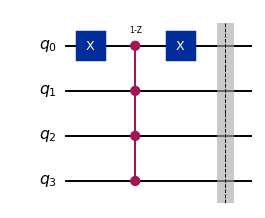

In [ ]:
# Apply an oracle/marking circuit to mark a specific state
marked_states = ["1110"]
oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp", scale=0.7)

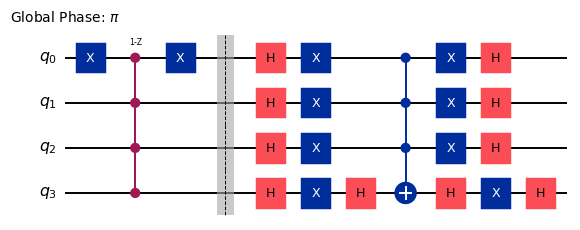

In [14]:
# using an oracle from before, create the Grover operator
grover_op = grover_operator(oracle)
grover_op.decompose(reps=0).draw(output="mpl", style="iqp", scale=0.7)

Optimal number of iterations: 3


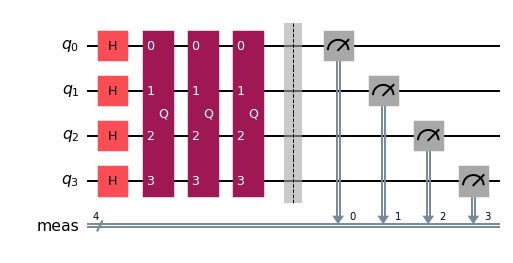

In [16]:
# Find optimal number of Grover iterations
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)
print(f"Optimal number of iterations: {optimal_num_iterations}")

# and build the full Grover circuit
qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl", style="iqp", scale=0.7)

In [ ]:
# Find least busy backend and create a Sampler instance
service = QiskitRuntimeService()
print("")
backend = service.least_busy()
print(f"Least busy backend: {backend.name}")
print(f"Has {backend.status().pending_jobs} pending jobs.")

qiskit_runtime_service.__init__:WARNING:2025-11-18 11:09:12,847: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: eloza. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


qiskit_runtime_service.backends:WARNING:2025-11-18 11:09:13,056: Using instance: eloza, plan: open


Least busy backend: ibm_fez
Has 0 pending jobs.


In [29]:
# use a preset pass manager to optimize our quantum circuit for the selected backend
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
circuit_isa = pm.run(qc)

# check the depth of the transpiled circuit
print("The total depth is ", circuit_isa.depth())
print(
    "The depth of two-qubit gates is ",
    circuit_isa.depth(lambda instruction: instruction.operation.num_qubits == 2),
)

# The transpiled circuit is very large, uncomment if you want to see it
# circuit_isa.draw(output="mpl", idle_wires=False, style="iqp", scale=0.7)

The total depth is  435
The depth of two-qubit gates is  113


In [36]:
# Create a Sampler job to run the circuit and save the job ID
sampler = Sampler(mode=backend)
sampler.options.default_shots = 20_000
job = sampler.run([circuit_isa])
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d4e4gfp2bisc73a14d90


In [40]:
# Retrieve the results using the job ID
job_id = "d4e4ec4nntuc73abpvqg"
# job = service.job(job_id)
res = job.result()
dist = res[0].data.meas.get_counts()

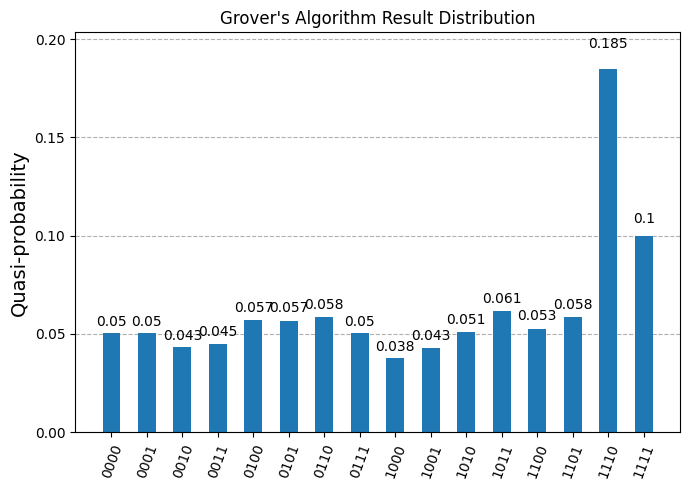

In [ ]:
# Postprocessing and visualization
plot_distribution(dist, title="Grover's Algorithm Result Distribution")